In [1]:
import torch
import torch.nn as nn

torch.set_default_device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "emb_drop_rate": 0.1,
    "shortcut_drop_rate": 0.1,
    "mha_drop_rate": 0.1,
    "qkv_bias": False,
}

In [3]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["emb_drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx: torch.Tensor):
        batch_size, seq_len = in_idx.shape

        # ["hello", "world"] -> [4.394, 1.685]
        tok_emb = self.tok_emb(in_idx)

        # [0, 1] -> [2.793, 1.164]
        pos_emb = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_emb + pos_emb

        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x


In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x: torch.Tensor):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


In [5]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]], device='mps:0')


In [6]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape: ", logits.shape)
print(logits)
tokenizer.decode_single_token_bytes(logits[0][-1].argmax())

Output shape:  torch.Size([2, 4, 50257])
tensor([[[ 0.9600, -0.1310,  0.4148,  ..., -1.2034, -1.6137, -0.9265],
         [ 0.6402,  0.5918,  0.0296,  ...,  0.9251, -0.7125, -1.1466],
         [ 0.9260,  0.3010, -0.5258,  ..., -0.2775, -0.4795,  1.7620],
         [ 0.0847, -0.9437,  0.3069,  ...,  0.1820, -0.9484,  0.1686]],

        [[ 0.1157, -0.2537,  0.2576,  ..., -0.5954, -1.4763, -0.9305],
         [-0.2500,  0.7868, -0.7587,  ...,  0.3725, -1.1292, -1.2134],
         [-0.4028,  0.0206,  0.1417,  ..., -0.1704,  1.3837, -0.0801],
         [ 0.8616, -0.6525, -1.1550,  ...,  1.3987, -0.2409, -0.0621]]],
       device='mps:0', grad_fn=<LinearBackward0>)


b' Unicorn'

In [7]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)
print(batch_example, "\n")

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[ 2.2035,  0.4599,  0.5828, -0.5727, -1.7389],
        [-0.1414, -1.7129, -0.3694,  0.5239,  0.4470]], device='mps:0') 

tensor([[0.7090, 0.0000, 1.6119, 0.0000, 0.0000, 0.0407],
        [0.3870, 0.5088, 0.0000, 0.5892, 0.0000, 0.1094]], device='mps:0',
       grad_fn=<ReluBackward0>)


In [8]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.3936],
        [0.2657]], device='mps:0', grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.4346],
        [0.0688]], device='mps:0', grad_fn=<VarBackward0>)


In [9]:
out_norm = (out - mean) / var.sqrt()
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.4784, -0.5970,  1.8480, -0.5970, -0.5970, -0.5353],
        [ 0.4621,  0.9265, -1.0130,  1.2332, -1.0130, -0.5959]],
       device='mps:0', grad_fn=<DivBackward0>)
Mean:
 tensor([[0.0000e+00],
        [7.9473e-08]], device='mps:0', grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.],
        [1.]], device='mps:0', grad_fn=<VarBackward0>)


In [10]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], device='mps:0', grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.],
        [1.]], device='mps:0', grad_fn=<VarBackward0>)


In [11]:
ln = LayerNorm(emb_dim=batch_example.size()[-1])
out_ln: torch.Tensor = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [-0.0000]], device='mps:0', grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], device='mps:0', grad_fn=<VarBackward0>)


In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2.0 / torch.pi))
                    * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )


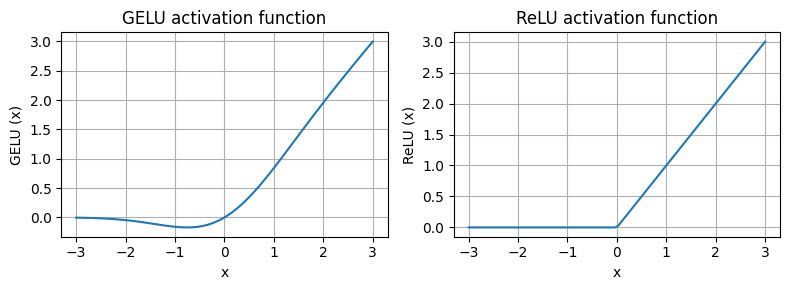

In [13]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x.cpu(), y.cpu())
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label} (x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [15]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)
out

torch.Size([2, 3, 768])


tensor([[[ 0.0048, -0.2015, -0.1308,  ...,  0.1208, -0.1679, -0.1558],
         [ 0.0791, -0.0583, -0.0798,  ...,  0.2449, -0.1511, -0.0155],
         [-0.0501, -0.1909, -0.0781,  ...,  0.1378, -0.0225, -0.0022]],

        [[ 0.1222, -0.1091, -0.0595,  ...,  0.2165, -0.0768, -0.1298],
         [ 0.2141, -0.2251, -0.1481,  ...,  0.1408, -0.1169, -0.0491],
         [ 0.0556, -0.0838, -0.0153,  ...,  0.1415,  0.0296,  0.0707]]],
       device='mps:0', grad_fn=<LinearBackward0>)

In [16]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
            ]
        )

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [17]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1.0, 0.0, -1.0]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes=layer_sizes, use_shortcut=False
)

In [18]:
def print_gradients(model: nn.Module, x):
    output: torch.Tensor = model(x)
    target = torch.tensor([[0.0]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [19]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0002162619202863425
layers.1.0.weight has gradient mean of 0.00035526612191461027
layers.2.0.weight has gradient mean of 0.0005182831664569676
layers.3.0.weight has gradient mean of 0.002068452537059784
layers.4.0.weight has gradient mean of 0.06016360968351364


In [20]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.012137016281485558
layers.1.0.weight has gradient mean of 0.011601612903177738
layers.2.0.weight has gradient mean of 0.010107418522238731
layers.3.0.weight has gradient mean of 0.026874244213104248
layers.4.0.weight has gradient mean of 0.15137353539466858


In [21]:
from gpt_from_scratch.attention import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            dropout=cfg["mha_drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = nn.LayerNorm(cfg["emb_dim"])
        self.norm2 = nn.LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["shortcut_drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


In [22]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [23]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["emb_drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = nn.LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [24]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]], device='mps:0')

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.3468,  0.6244,  0.1494,  ...,  1.0839,  0.8516, -0.4183],
         [ 0.9577, -0.0221, -0.6267,  ..., -0.4245,  0.4766, -0.8899],
         [-0.3522, -0.0285,  0.9603,  ...,  1.3693,  0.9676, -0.8266],
         [ 0.2245,  0.4442, -0.7965,  ...,  0.1623,  0.4081, -0.1631]],

        [[-0.1685,  0.0506,  0.0359,  ...,  1.1151,  0.5318, -0.6387],
         [ 0.4135, -0.1107, -0.4152,  ..., -0.0807,  1.0618, -0.2657],
         [ 0.6735,  0.1685,  0.0559,  ...,  0.5398,  0.7944, -0.3199],
         [-0.3052,  0.2157, -0.7526,  ..., -0.4642,  0.3621, -2.0256]]],
       device='mps:0', grad_fn=<LinearBackward0>)


In [25]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [26]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [27]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())

print(f"Number of trainable paramters considering weight tying: {total_params_gpt2:,}")

Number of trainable paramters considering weight tying: 124,412,160


In [28]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


# Next: 4.7


In [29]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [30]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [31]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 25706, 37699, 38992, 17425, 34410,  7147]],
       device='mps:0')
Output length: 10


In [32]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am tan flap Anita configure Paulo chosen
